In [2]:
# Import necessary libraries
import os
from pathlib import Path
import numpy as np
import pandas as pd
from astropy import coordinates as coords
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.table import Table
from astropy.io import fits
from astropy.cosmology import LambdaCDM
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Set cosmology
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

plt.rcParams.update({
    "font.family": 'STIXGeneral',
    'text.usetex': False,
    "mathtext.fontset": 'cm',
    "axes.labelweight": "normal",
    'font.size': 25,
    'font.weight': 'normal',
    
    # Tick direction and appearance
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,            # show top ticks
    'ytick.right': True,          # show right ticks
    'xtick.minor.visible': True,  # show minor x ticks
    'ytick.minor.visible': True,  # show minor y ticks
    'xtick.major.size': 10,
    'xtick.minor.size': 6,
    'ytick.major.size': 10,
    'ytick.minor.size': 6,
    'xtick.major.width': 1.6,
    'xtick.minor.width': 1.6,
    'ytick.major.width': 1.6,
    'ytick.minor.width': 1.6,
    
    # Axes and line properties
    'lines.linewidth': 2,
    'axes.linewidth': 3.5,
    'axes.labelpad': 4,
    'xtick.major.pad': 7,
    'image.origin': 'lower'
})
# Pandas configuration
pd.set_option('display.max_columns', None)

In [ ]:
hecs_vac_data = pd.read_csv('../../DATA/AllHeCS_VAC_updated.csv')
Z_CLID = hecs_vac_data[hecs_vac_data['CLID']=='Coma']['Z'].values[0]

df = pd.read_csv('../../DATA/Coma/Coma_mastercat_within35arcmin.csv')
df['p_petromag_r_0'] = df['p_petromag_r'] - df['p_extinction_r']
# 1. Get function for SDSS SB correction factor (Blanton et al. 2005?)
blanton = pd.read_csv('../../DATA/Blanton2005correctionFactor.txt', 
                 delim_whitespace=True, 
                 skiprows=1, 
                 names=['absmag', 'CorrectionFactor'])

/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_68643/2581494635.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  blanton = pd.read_csv('../../DATA/Blanton2005correctionFactor.txt',


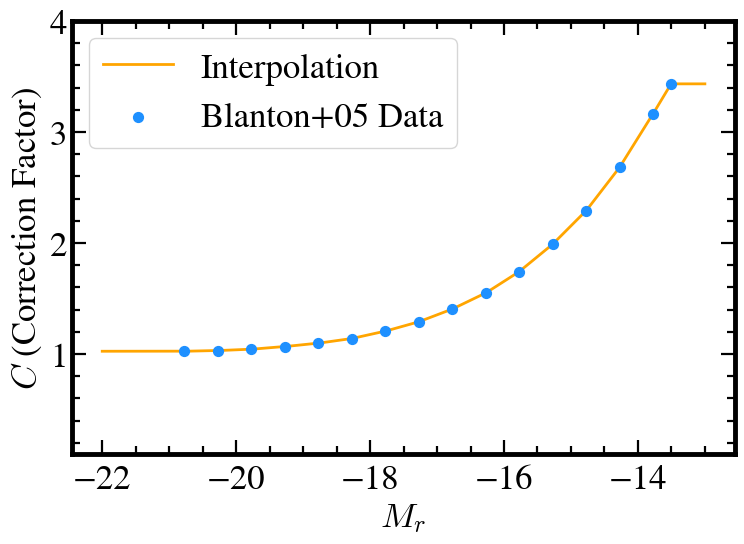

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def C_sbcor(X):
    """
    Interpolates the SDSS surface brightness correction factor (Blanton et al. 2005)
    for a given input absolute magnitude X.
    """
    x = float(X)
    absmag = blanton['absmag']
    corr = blanton['CorrectionFactor']
    if x <= absmag.min():
        return corr.iloc[0]
    elif x >= absmag.max():
        return corr.iloc[-1]
    else:
        # Find the two bounding absmag rows
        i_upper = np.searchsorted(absmag.values, x, side='right')
        i_lower = i_upper - 1
        x0, y0 = absmag.iloc[i_lower], corr.iloc[i_lower]
        x1, y1 = absmag.iloc[i_upper], corr.iloc[i_upper]
        return y0 + (y1 - y0) * (x - x0) / (x1 - x0)

# Interpolation curve for plotting
x_vals = np.linspace(-22, -13, 500)
y_vals = [C_sbcor(x) for x in x_vals]

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x_vals, y_vals, color='orange', label='Interpolation')
ax.scatter(blanton['absmag'], blanton['CorrectionFactor'], color='dodgerblue', s=50, zorder=10, label='Blanton+05 Data')
ax.set_xlabel(r'$M_r$')
ax.set_ylabel(r'$C$ (Correction Factor)')
ax.set_ylim([0.1, 4])
ax.legend()
plt.tight_layout()
plt.show()

/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_68643/2711714668.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = cluster_data.groupby(bins)


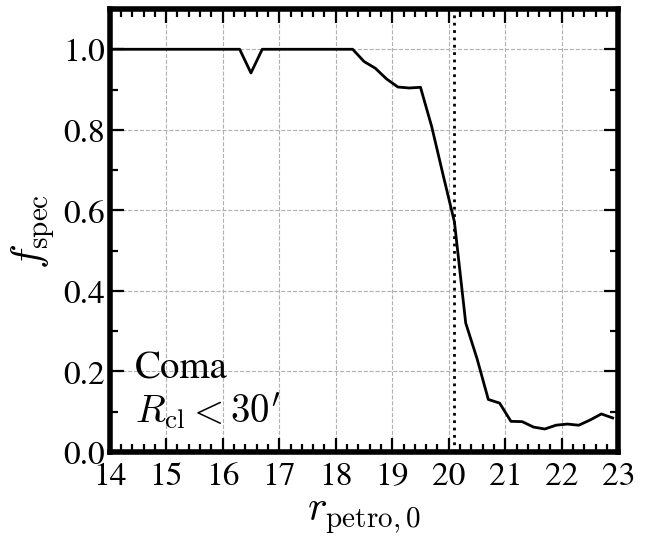

Cluster Coma (Rcl_arcmin < 30):
  Cumulative f_spec > 0.90 at r_petro = 19.70
  Value f_spec > 0.50 at r_petro = 20.10


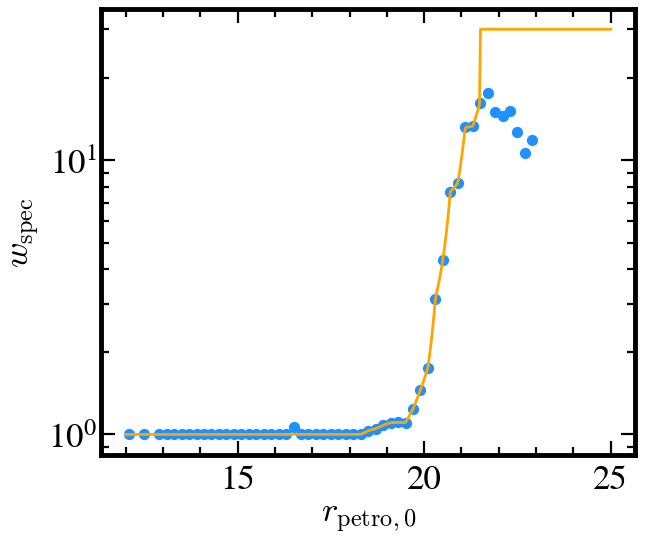

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator

d_lum = cosmo.luminosity_distance(Z_CLID).to('pc').value 
DM = 5 * np.log10(d_lum) - 5
spec_comp_limit = 20.8 - DM

# --- PARAMETERS ---
cluster_id = "Coma"

# --- DATA SELECTION & PREPROCESSING ---
# Select galaxies within Rcl_arcmin < 30
cluster_data = df[(df['p_radgal'] < 30) & (df['p_probpsf'] == 0)].copy()
cluster_data['p_petromag_r_0'] = cluster_data['p_petromag_r'] - cluster_data['p_extinction_r']

# --- BINNING ---
bin_width = 0.2
bin_edges = np.arange(12, 23 + bin_width, bin_width)
bins = pd.cut(cluster_data['p_petromag_r_0'], bins=bin_edges, include_lowest=False)

# --- BIN STATS ---
grouped = cluster_data.groupby(bins)
total_counts = grouped.size()
valid_z_counts = grouped.apply(lambda x: (x['z_tot_z'] != -9.0).sum())

bin_centers = [round(interval.mid, 2) for interval in bins.cat.categories]

# --- RATIOS (PER BIN & CUMULATIVE) ---
ratios = (valid_z_counts / total_counts).fillna(0)
ratios.index = bin_centers

cumulative_valid = valid_z_counts.cumsum()
cumulative_total = total_counts.cumsum()
cumulative_ratios = (cumulative_valid / cumulative_total).fillna(0)
cumulative_ratios.index = bin_centers

# --- BIN THRESHOLDS ---
bin_cum90 = next((x for x in reversed(bin_centers) if cumulative_ratios.get(x, 0) > 0.90), None)
bin_val50 = next((x for x in reversed(bin_centers) if ratios.get(x, 0) > 0.50), None)

# --- RATIO PLOT ---
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(ratios.index, ratios, '-', color='black', lw=2)
ax.set_xlim(14, 23)
ax.set_xticks(np.arange(14, 23, 1))
ax.set_ylim([0, 1.1])
ax.xaxis.set_minor_locator(MultipleLocator(0.2))
ax.yaxis.set_minor_locator(MultipleLocator(0.1))
ax.grid(which='major', axis='both', linestyle='--', linewidth=0.8)
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.yaxis.set_major_locator(MultipleLocator(0.2))
ax.set_ylabel(r'$f_\mathrm{spec}$', fontsize=30)
ax.set_xlabel(r'$r_{\mathrm{petro,0}}$', fontsize=30)
ax.tick_params(which='both', top=True, right=True, labelsize=24)

# Add line for threshold
if bin_val50 is not None:
    ax.axvline(x=bin_val50, color='black', linestyle=':', linewidth=2, label=r'$f_\mathrm{spec} > 0.5$')

# Annotations
ax.text(0.05, 0.15, cluster_id, transform=ax.transAxes, fontsize=28, ha='left', va='bottom')
ax.text(0.05, 0.05, r'$R_\mathrm{cl}<30^\prime$', transform=ax.transAxes, fontsize=28, ha='left', va='bottom')

# Thicker axis lines
for spine in ax.spines.values():
    spine.set_linewidth(4)

plt.tight_layout()
plt.show()

# --- INFO PRINT ---
print(f"Cluster {cluster_id} (Rcl_arcmin < 30):")
if bin_cum90 is not None:
    print(f"  Cumulative f_spec > 0.90 at r_petro = {bin_cum90:.2f}")
if bin_val50 is not None:
    print(f"  Value f_spec > 0.50 at r_petro = {bin_val50:.2f}")

# --- BUILD f_spec TABLE ---
f_spec_df = pd.DataFrame({
    'p_petromag_r_0': ratios.index,
    'total_galaxies': total_counts.values,
    'valid_redshifts': valid_z_counts.values,
    'f_spec': ratios.values
}).sort_values(by='p_petromag_r_0').reset_index(drop=True)

# --- w_spec FUNCTION ---
def w_spec(X):
    X = float(X)
    if X <= 17:
        return 1.0
    if X >= 21.5:
        return 30.0
    lower = f_spec_df[f_spec_df['p_petromag_r_0'] <= X].iloc[-1]
    upper = f_spec_df[f_spec_df['p_petromag_r_0'] > X].iloc[0]
    x0, y0 = lower['p_petromag_r_0'], lower['f_spec']
    x1, y1 = upper['p_petromag_r_0'], upper['f_spec']
    interp = y0 + (y1 - y0) * (X - x0) / (x1 - x0)
    return 1.0 / interp

# --- w_spec CURVE PLOT ---
x_vals = np.linspace(12, 25, 500)
y_vals = [w_spec(x) for x in x_vals]

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(x_vals, y_vals, color='orange')
ax.scatter(f_spec_df['p_petromag_r_0'], 1/f_spec_df['f_spec'], color='dodgerblue', s=50)
ax.set_xlabel(r'$r_\mathrm{petro, 0}$')
ax.set_ylabel(r'$w_\mathrm{spec}$')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

# 3. Luminosity Function of Coma

/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_68643/3819085589.py:25: RuntimeWarning: invalid value encountered in sqrt
  yerr_raw_lower = np.sqrt(hist_raw - 0.25)


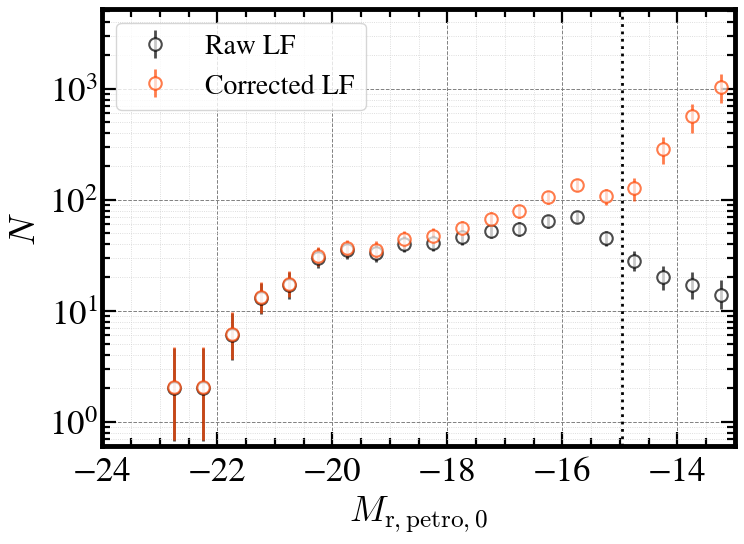

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Filter cluster member galaxies within Rcl_arcmin < 30 and galaxy-like morphology
df_plot = df[
    (df['p_radgal'] < 30) & 
    (df['p_probpsf'] == 0) & 
    (df['member'] == 1)
].copy()

# Apply surface brightness correction and spectroscopic completeness
df_plot['C_sbcor'] = df_plot['p_petromag_r_absmag'].apply(C_sbcor)
df_plot['w_spec'] = df_plot['p_petromag_r_0'].apply(w_spec)
df_plot['weight'] = df_plot['C_sbcor'] * df_plot['w_spec']

# Define magnitude bins
bin_width = 0.5
bin_edges = np.arange(-24, -12 + bin_width, bin_width)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Unweighted LF histogram and errors
hist_raw, _ = np.histogram(df_plot['p_petromag_r_absmag'], bins=bin_edges)
yerr_raw_upper = np.sqrt(hist_raw + 0.75) + 1
yerr_raw_lower = np.sqrt(hist_raw - 0.25)

# Weighted LF histogram and Poisson-like errors
hist_weighted, _ = np.histogram(df_plot['p_petromag_r_absmag'], bins=bin_edges, weights=df_plot['weight'])
var_weighted, _ = np.histogram(df_plot['p_petromag_r_absmag'], bins=bin_edges, weights=(df_plot['weight'] ** 2))
yerr_weighted_upper = np.sqrt(var_weighted + 0.75) + 1
yerr_weighted_lower = np.sqrt(np.maximum(var_weighted - 0.25, 0))

# Plot raw and corrected luminosity function
fig, ax = plt.subplots(figsize=(8, 6))

mask_raw = hist_raw > 0
ax.errorbar(
    bin_centers[mask_raw], hist_raw[mask_raw],
    yerr=[yerr_raw_lower[mask_raw], yerr_raw_upper[mask_raw]],
    fmt='o', color='black', ecolor='black',
    markerfacecolor='white', markeredgewidth=1.5, capsize=0,
    label='Raw LF', alpha=0.7, markersize=9
)

mask_corr = hist_weighted > 0
ax.errorbar(
    bin_centers[mask_corr], hist_weighted[mask_corr],
    yerr=[yerr_weighted_lower[mask_corr], yerr_weighted_upper[mask_corr]],
    fmt='o', color='orangered', ecolor='orangered',
    markerfacecolor='white', markeredgewidth=1.5, capsize=0,
    label='Corrected LF', alpha=0.7, markersize=9
)

ax.set_yscale('log')
ax.set_xlim(-24, -13)
ax.set_ylim([0.6, 5 * max(hist_raw.max(), hist_weighted.max())])
ax.set_xlabel(r'$M_\mathrm{r,petro,0}$', fontsize=26)
ax.set_ylabel(r'$N$', fontsize=26)

ax.grid(True, which='major', color='gray', linestyle='--', linewidth=0.7)
ax.grid(True, which='minor', color='lightgray', linestyle=':', linewidth=0.6)
ax.minorticks_on()
ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax.legend(fontsize=20, loc='upper left')

# Mark magnitude completeness (20.7 - DM) if DM is defined
ax.axvline(20.7 - DM, color='black', linestyle=':', linewidth=2)

plt.tight_layout()
plt.show()

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import astropy.units as u
import emcee

# --- Define Schechter function ---
def schechter_1D_LF(M, phi_0, M_star, alpha):
    exponent = 10 ** (0.4 * (M_star - M))
    return phi_0 * exponent ** (1 + alpha) * np.exp(-exponent)

# --- Define log-probability components ---
def log_likelihood(theta, M, y, yerr):
    phi_0, M_star, alpha = theta
    model_density = schechter_1D_LF(M, phi_0, M_star, alpha)
    model_counts = model_density * bin_width * volume_h3  # Convert to counts
    sigma2 = yerr ** 2
    return -0.5 * np.sum((y - model_counts) ** 2 / sigma2 + np.log(2 * np.pi * sigma2))

def log_prior(theta):
    phi_0, M_star, alpha = theta
    if 0 < phi_0 < 100 and -24 < M_star < -14 and -3 < alpha < 0:
        return 0.0
    return -np.inf

def log_probability(theta, M, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, M, y, yerr)

# --- Cosmology ---
h = cosmo.H0.value / 100.0
z = Z_CLID
comoving_distance = cosmo.comoving_distance(z)
theta = 30 * u.arcmin
transverse_comoving_distance = comoving_distance * (theta.to(u.radian) / u.radian)
comoving_volume = 3 * np.pi * transverse_comoving_distance**3
volume_h3 = comoving_volume.value * h**3

# --- Histogram Binning ---
bin_width = 0.5
bin_edges = np.arange(-24, -12 + bin_width, bin_width)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

# --- Histograms (raw & corrected) ---
weights = df_plot['weight']
hist_raw, _ = np.histogram(df_plot['p_petromag_r_absmag'], bins=bin_edges)
hist_corr, _ = np.histogram(df_plot['p_petromag_r_absmag'], bins=bin_edges, weights=weights)
weight_squared = df_plot['weight'] ** 2
variance_corr, _ = np.histogram(df_plot['p_petromag_r_absmag'], bins=bin_edges, weights=weight_squared)

# --- Error bars ---
yerr_upper_raw = np.sqrt(hist_raw + 0.75) + 1
yerr_lower_raw = np.sqrt(hist_raw - 0.25)
yerr_upper_corr = np.sqrt(variance_corr + 0.75) + 1
yerr_lower_corr = np.sqrt(np.maximum(variance_corr - 0.25, 0))
yerr_corr = np.sqrt(variance_corr)

# --- MCMC Fit to unnormalized data (counts per bin) ---
fit_range = (-24, spec_comp_limit)
mask_fit = (bin_centers > fit_range[0]) & (bin_centers < fit_range[1]) & (hist_corr > 0)
x_fit = bin_centers[mask_fit]
y_fit = hist_corr[mask_fit]
yerr_fit = yerr_corr[mask_fit]

initial = np.array([10, -21.35, -1.24])
nwalkers, ndim = 42, initial.size
pos = initial + 1e-4 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(x_fit, y_fit, yerr_fit))
sampler.run_mcmc(pos, 5000, progress=True)

# --- Extract MCMC result ---
samples = sampler.get_chain(discard=1000, thin=15, flat=True)
phi0_lo, phi0_med, phi0_hi = np.percentile(samples[:, 0], [16, 50, 84])
mstar_lo, mstar_med, mstar_hi = np.percentile(samples[:, 1], [16, 50, 84])
alpha_lo, alpha_med, alpha_hi = np.percentile(samples[:, 2], [16, 50, 84])
phi0_err = [phi0_med - phi0_lo, phi0_hi - phi0_med]
M_star_err = [mstar_med - mstar_lo, mstar_hi - mstar_med]
alpha_err = [alpha_med - alpha_lo, alpha_hi - alpha_med]

/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_68643/4081131489.py:55: RuntimeWarning: invalid value encountered in sqrt
  yerr_lower_raw = np.sqrt(hist_raw - 0.25)
100%|██████████| 5000/5000 [00:03<00:00, 1313.98it/s]


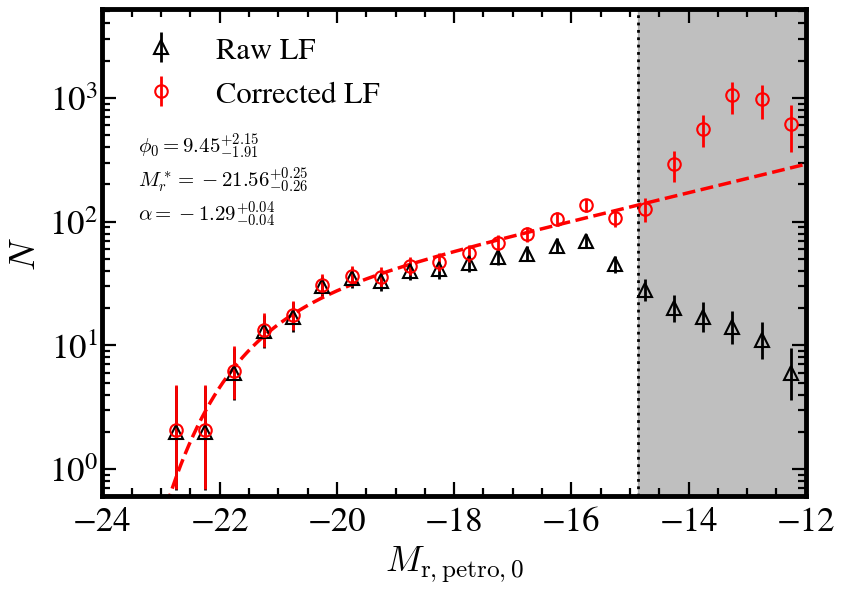

In [13]:
# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 6.5))

# Raw LF
mask_raw = hist_raw > 0
ax.errorbar(bin_centers[mask_raw], hist_raw[mask_raw],
            yerr=[yerr_lower_raw[mask_raw], yerr_upper_raw[mask_raw]],
            fmt='^', color='black', ecolor='black',
            markerfacecolor='none', markeredgewidth=1.5, capsize=0,
            label='Raw LF', alpha=1.0, markersize=10)

# Corrected LF (used for fitting)
mask_corr = hist_corr > 0
ax.errorbar(bin_centers[mask_corr], hist_corr[mask_corr],
            yerr=[yerr_lower_corr[mask_corr], yerr_upper_corr[mask_corr]],
            fmt='o', color='red', ecolor='red',
            markerfacecolor='none', markeredgewidth=1.5, capsize=0,
            label='Corrected LF', alpha=1.0, markersize=9, zorder=2)

# MCMC model (converted to counts)
x_model = np.linspace(-24, -12, 1000)
y_model_density = schechter_1D_LF(x_model, phi0_med, mstar_med, alpha_med)
y_model = y_model_density * bin_width * volume_h3
ax.plot(x_model, y_model, color='red', linestyle='--', lw=2.5)

# Axes and labels
ax.set_yscale('log')
ax.set_xlim(-24, -12)
ax.set_ylim([0.6, max(hist_raw.max(), hist_corr.max()) * 5])
ax.set_xlabel(r'$M_\mathrm{r,petro,0}$', fontsize=26)
ax.set_ylabel(r'$N$', fontsize=26)
ax.minorticks_on()
ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax.legend(fontsize=22, loc='upper left', frameon=False)

ax.axvline(spec_comp_limit, color='black', linestyle=':', linewidth=2)
ax.axvspan(spec_comp_limit, -12, color='gray', alpha=0.5)

# Annotation with fit parameters
annotation_text = (
    r"$\phi_0 = {:.2f}^{{+{:.2f}}}_{{-{:.2f}}}$".format(phi0_med, phi0_err[1], phi0_err[0]) + "\n" +
    r"$M^*_r = {:.2f}^{{+{:.2f}}}_{{-{:.2f}}}$".format(mstar_med, M_star_err[1], M_star_err[0]) + "\n" +
    r"$\alpha = {:.2f}^{{+{:.2f}}}_{{-{:.2f}}}$".format(alpha_med, alpha_err[1], alpha_err[0])
)
ax.text(0.05, 0.75, annotation_text, transform=ax.transAxes,
        fontsize=15, verticalalignment='top', horizontalalignment='left',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='none', edgecolor='none', alpha=0.8))

plt.tight_layout()
# plt.savefig('/Users/jonginpark/A2199_LF/FIGURE/images/A2199_LF.pdf', bbox_inches='tight', dpi=1000)
plt.show()
